In [7]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles

In [8]:
N_cheb = 199
Mr = 0.3
gamma = 1.4
sigma = 0.72
Ro = 0.313
Co = 2-Ro-Ro^2
Tw = 1
R =200
Ma = Mr/R
omega = 0
be1 = 0.2
c = 0.6
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro);
H,T = T_ca(Mr,f,q,w0,gamma,Tw);
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim");
lam = - (2/3) * T;
kappa = (1/sigma) * T;
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ = c , neigs = 3 ,maxit = 500,tol=1e-10)


(ComplexF64[0.8279630039319571 - 0.01762441757861684im, 0.3892763371668463 + 0.11595782375507652im, 0.4139663691739194 + 0.15426260074096781im], ComplexF64[-1.5379918614908305e-6 + 4.3440371957999616e-5im 2.1764376507295356e-5 + 4.153777098897396e-6im 2.7662265949193353e-6 - 1.91766933095713e-6im; -6.081820437399013e-6 + 0.0001737017585981633im 8.706458462933125e-5 + 1.6602676212149915e-5im 1.1091302093065155e-5 - 7.650839699064726e-6im; … ; 2.059241449234306e-14 - 4.5920298813451055e-14im 1.0186925088195853e-13 + 5.1766316927492895e-14im -4.882849224778496e-12 + 6.85327554254822e-11im; -9.1148174282365e-16 + 3.394019789255591e-15im 1.851815724084835e-14 + 1.09714984828579e-14im -1.7464134113525444e-12 + 1.1338502977461863e-11im], ComplexF64[-0.04699350805853216 + 0.0im -6.755563901442533e-5 + 0.0006648742886428339im … 0.0005793549793819258 + 8.61386452516732e-5im 0.0013278995162772254 - 0.0007315061441225189im; 0.04586578744802113 + 0.0im 0.00013897190287916495 - 0.0004871213436057519

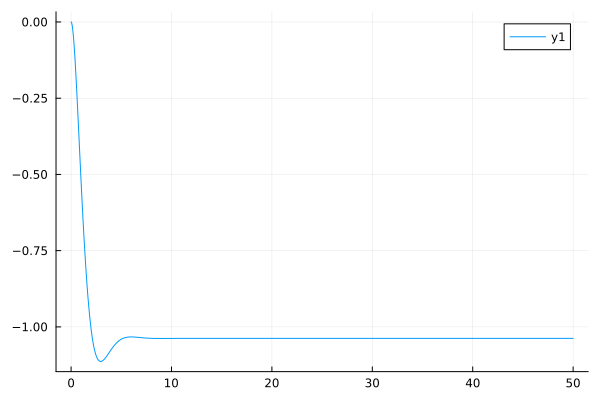

In [9]:
plot(x,H)

In [13]:
##DIRECTLY CACULATE CUR
##initial
        Mr = 0.3
        Tw = 1
        N_cheb = 59
        omega = 0

        gamma = 1.4
        sigma = 0.72
        global R = 200
        R_step = 0.5
        be1 = 0.15
        be_step = -0.001
        c = 0.5
        num = 1
        Ro = 0.313
        Co = 2-Ro-Ro^2
        Ma = Mr/R
        global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro)
        H,T = T_ca(Mr,f,q,w0,gamma,Tw)
        F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
        lam = - (2/3) * T
        kappa = (1/sigma) * T
        global initial_i = []
        global initial_r = []
        global tempvec_i = [0 0 0 0]
        global tempvec_r = [0 0 0 0]
        global mode = 0
        writedlm("output_$Tw _ $Mr.dat",initial_i)
        writedlm("output_eig.dat",initial_r)
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
        # eigval = conj(eigval)
        if imag(eigval[1]) < 0
            for be = be1 : -1 * be_step : 0.5

            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
            # eigval = conj(eigval)
            point = filter(x ->  - 0.0015 < imag(x) < 0.0015, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
            end
        elseif imag(eigval[1]) > 0
            for be = be1 : 1 * be_step : -0.1

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
                # eigval = conj(eigval)
                point = filter(x ->  - 0.001 < imag(x) < 0.0005, eigval)
                open("output_eig.dat", "a") do io
                    write(io,"be=$be,eig=$eigval\n")
                end
                if point != []
                    global initial_i = [omega R be imag(point)]
                    global initial_r = [omega R be real(point)]
                    break
                end
            end
        end
        global total_r = initial_r
        global total_i = initial_i

    # CACULATE

        for be = initial_r[1,3] +  be_step  :  be_step : -0.2

            # if total_i[end,2] <40
            #     num = 5
            # else
            #     num = 1
            # end
            num = 1
            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 2 * be_step,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
            # eigval_1 = conj(eigval_1)
            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be - 2 * be_step,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
            # eigval_2 = conj(eigval_2)
            if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

            global mode = 1

            elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

            global mode = 2

            end
            
            if length(total_r[:,1]) > 2 

            grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
            else

            grad = 0

            end
            

            if mode == 1 



                for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 0
                    Ma = Mr/R
                    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                    nep = PEP([A0,A1,A2]); 
                    pre = total_r[end,4] - im * total_i[end,4]
                    eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                    # eigval = conj(eigval)
                    # index = findmin(abs.(imag(eigval)))
                    
                    global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                    global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                    len = size(tempvec_i,1)

                    open("output_$Tw _ $Mr.dat", "a") do io
                        write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                    end

                    if tempvec_i[end- 1 ,4] * tempvec_i[end,4] < 0

                        global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                        global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]

                        tempvec_i = [0 0 0 0]
                        tempvec_r = [0 0 0 0]
                        
                        break
                    end
                    
                    if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                        mode = 2
                        tempvec_i = [0 0 0 0]
                        tempvec_r = [0 0 0 0]
                        break
                        
                    end
                end        
            end


            if mode == 2

                for R = total_r[end,2] + 0 * grad * be_step: R_step : 600
                    Ma = Mr/R
                    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                    nep = PEP([A0,A1,A2]); 
                    eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                    # eigval = conj(eigval)
                    # index = findmin(abs.(imag(eigval)))
                    global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                    global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]



                    len = size(tempvec_i,1)

                    open("output_$Tw _ $Mr.dat", "a") do io
                        write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                    end

                    if tempvec_i[end - 1,4] * tempvec_i[end,4] < 0
                        global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                        global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]
                        global tempvec_i = [0 0 0 0]
                        global tempvec_r = [0 0 0 0]
                        break

                    end

                    if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                        global mode = 1
                        global tempvec_i = [0 0 0 0]
                        global tempvec_r = [0 0 0 0]
                        break
                        
                    end
                end
            end

            if mode == 1
                
                for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
                    Ma = Mr/R

                    if total_i[end,3] == be

                        break

                    end 

                    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                    nep = PEP([A0,A1,A2]); 
                    eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                    # eigval = conj(eigval)
                    # index = findmin(abs.(imag(eigval)))
                    global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                    global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                    len = size(tempvec_i,1)

                    open("output_$Tw _ $Mr.dat", "a") do io
                        write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                    end

                    if tempvec_i[end - 1,4] * tempvec_i[end,4] < 0
                        global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                        global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]
                        global tempvec_i = [0 0 0 0]
                        global tempvec_r = [0 0 0 0]
                        break
                    end
                    
                    if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                    global mode = 2
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                        break
                        
                    end

                end     
            end
    
            if total_i[end,2]>210 && size(total_i,1)>100
                break
            end
            # if total_i[end,2]>total_i[end-1,2]
            #     break
            # end

        end

        writedlm("$omega _$Tw _$Mr _i.dat",total_i)
        writedlm("$omega _$Tw _$Mr _r.dat",total_r)

        end
    end
end

InterruptException: InterruptException: